## 01. 회귀 기반 추천 시스템

회귀 기반 추천은 추천 문제를 “점수 예측 문제”로 바꾸어 해결하는 방식이다.

### 회귀 기반 추천 시스템흐름

1. 추천 후보를 준비한다.
2. 사용자 조건과 후보 정보를 모델에 넣는다.
3. 모델이 후보별 예상 점수를 예측한다.
4. 예측 점수가 높은 후보를 위로 정렬한다.
5. 정렬 결과의 상위 항목을 추천 결과로 사용한다.

예를 들어 여행지 추천에서는 사용자의 성별, 연령대, 여행 스타일, 이동수단, 후보 여행지 같은 정보를 입력으로 넣고, 해당 여행지에 대한 예상 만족도 점수를 예측한다.  
이후 예측 만족도가 높은 여행지를 위에서부터 추천한다.

---

**왜 회귀 모델로 추천을 만들 수 있는가?**

회귀 모델은 숫자를 예측하는 모델이다.  
추천 문제에서 예측하고 싶은 값을 “만족도”, “평점”, “구매 가능 점수”, “클릭 가능 점수”처럼 숫자로 정의하면 회귀 모델을 추천에 활용할 수 있다.

이 노트북에서는 `DGSTFN` 만족도 점수를 예측한다.  
따라서 모델이 출력하는 값은 “이 사용자가 이 방문지를 갔을 때 예상되는 만족도”로 해석한다.

---

**사용하는 모델: CatBoostRegressor**

CatBoostRegressor는 여러 개의 트리를 순서대로 학습하면서 오차를 줄여가는 부스팅 계열 회귀 모델이다.

범주형 feature를 비교적 편하게 다룰 수 있어 여행 지역, 이동수단, 여행 목적처럼 문자열이나 범주형 값이 많은 추천 예제에 잘 맞는다.

---

**확인할 평가 지표**

- MAE: 예측 만족도와 실제 만족도의 차이를 절댓값으로 평균낸 값이다. 낮을수록 좋음.
- RMSE: 큰 오차에 더 민감한 회귀 오차 지표이다. 낮을수록 좋음.
- R2: 평균값으로 예측하는 것보다 모델이 target 변화를 얼마나 더 잘 설명하는지 보는 지표이다. 1에 가까울수록 좋음.

추천 시스템에서는 평가 지표가 좋다고 바로 좋은 서비스가 되는 것은 아니다.  
모델이 예측한 점수를 기준으로 후보를 정렬했을 때 실제 사용자가 만족할 만한 추천 목록이 만들어지는지도 함께 봐야 한다.

---

**이 방식의 한계**

회귀 기반 추천은 “사용자와 후보 항목을 넣으면 점수를 예측한다”는 구조가 단순해서 이해하기 쉽다.  
하지만 사용자의 장기 행동 이력, 다른 사용자와의 유사성, 최신 선호 변화까지 모두 자동으로 반영하는 고도화된 추천 시스템은 아니다.

따라서 이 노트북은 추천 시스템 전체를 완성하는 단원이라기보다, 추천 시스템의 기본 구조인 “후보 생성 → 점수 예측 → 정렬”을 이해하기 위한 첫 번째 실습이다.


## 02. 추천 시스템을 가장 쉽게 시작하는 방법

추천 시스템을 처음 배울 때는 “복잡한 알고리즘”보다 “추천이 만들어지는 구조”를 먼저 보는 것이 좋다.

회귀 기반 추천은 추천 문제를 다음처럼 단순화한다.

```text
사용자 조건 + 후보 항목 정보 -> 예상 점수 예측 -> 점수순 정렬 -> 추천
```

여기서 중요한 점은 모델이 바로 “추천 목록”을 만들어주는 것이 아니라는 점이다.  
모델은 후보별 예상 점수를 예측하고, 우리는 그 점수를 기준으로 후보를 정렬해 추천 목록을 만든다.

이번 실습에서는 여행 데이터를 사용해 다음 질문에 답한다.

> 이 사용자 조건에서 어떤 방문지가 높은 만족도를 받을 가능성이 있는가?


## 03. 제주도 여행데이터

https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71584

이 데이터는 제주도 여행자의 기본 정보, 여행 스타일, 여행 동기, 방문지, 이동수단, 만족도 점수를 담고 있다.
여행자 조건과 후보 방문지 정보를 입력으로 넣고, `DGSTFN` 만족도 점수를 예측한 뒤 점수가 높은 방문지를 추천한다.

**컬럼 구성**

| 컬럼 | 의미 | 추천 모델에서의 역할 |
|---|---|---|
| `GENDER` | 여행자 성별 | 입력 feature |
| `AGE_GRP` | 여행자 연령대 코드 | 입력 feature |
| `TRAVEL_STYL_1` ~ `TRAVEL_STYL_8` | 여행 스타일 관련 설문 응답 코드값 | 입력 feature |
| `TRAVEL_MOTIVE_1` | 주요 여행 동기 코드 | 입력 feature |
| `TRAVEL_COMPANIONS_NUM` | 여행 동반자 수 | 입력 feature |
| `VISIT_AREA_NM` | 방문지 이름 | 추천 후보이자 입력 feature |
| `MVMN_NM` | 이동수단 이름 | 입력 feature |
| `DGSTFN` | 방문지 만족도 점수 | 예측할 target |

**학습 포인트**

- `GENDER`, `VISIT_AREA_NM`, `MVMN_NM`은 문자열 범주형 feature이다.
- `AGE_GRP`, `TRAVEL_STYL_*`, `TRAVEL_MOTIVE_1`, `TRAVEL_COMPANIONS_NUM`은 숫자로 보이지만 실제 의미는 코드값에 가까운 범주형 feature이다.
- `DGSTFN`은 모델이 맞혀야 하는 정답값이다. 이 값이 높게 예측되는 방문지를 추천 후보 상위에 배치한다.
- 따라서 이 예제는 “사용자 조건 + 후보 방문지 → 예상 만족도 점수”를 예측하는 회귀 기반 추천 문제이다.


## 04. 실습 환경 준비

- 라이브러리 import가 끝나면 데이터 처리, 모델 학습, 평가에 필요한 도구를 사용할 수 있음.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from streamlit.runtime.caching.storage import local_disk_cache_storage


## 05. 데이터 로드와 기본 확인

- 데이터 로드는 모델 학습 전에 컬럼 의미, 행/열 크기, target 분포를 확인하는 출발점임.


In [2]:
travel_df = pd.read_csv('data/travel.csv')
travel_df.head()


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM,DGSTFN
0,남,30.0,1.0,4.0,2.0,2.0,6.0,2.0,2.0,7.0,3.0,3.0,미스틱3도,자가용,5.0
1,남,20.0,4.0,1.0,5.0,1.0,1.0,4.0,1.0,6.0,3.0,1.0,에스제이렌트카,대중교통 등,4.0
2,여,50.0,4.0,1.0,2.0,4.0,3.0,3.0,2.0,3.0,1.0,3.0,법환식당,대중교통 등,5.0
3,남,30.0,1.0,1.0,1.0,5.0,6.0,3.0,5.0,7.0,7.0,3.0,에코랜드호텔,자가용,5.0
4,여,20.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,5.0,1.0,2.0,윤스타피자앤파스타,자가용,4.0


## 06. 범주형 feature 타입 정리

- 여행 스타일과 동기 컬럼을 모델에 전달하기 전에 일관된 정수형 범주 값으로 정리함.


In [3]:
travel_df[['AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
       'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
       'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM']] = travel_df.iloc[:, 1:-3].astype(int)

## 07. 데이터 구조 확인

- 자료형이 숫자인지 범주형인지, 결측치가 있는지에 따라 인코딩과 결측치 처리 방법이 달라짐.


In [4]:
travel_df.info()

# info() 결과
# - 모든 컬럼이 non-null -> 결측치 없음
# - 숫자 범주형 컬럼의 dtype 이 모두 int로 변환되어있음.

<class 'pandas.DataFrame'>
RangeIndex: 34572 entries, 0 to 34571
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENDER                 34572 non-null  str    
 1   AGE_GRP                34572 non-null  int64  
 2   TRAVEL_STYL_1          34572 non-null  int64  
 3   TRAVEL_STYL_2          34572 non-null  int64  
 4   TRAVEL_STYL_3          34572 non-null  int64  
 5   TRAVEL_STYL_4          34572 non-null  int64  
 6   TRAVEL_STYL_5          34572 non-null  int64  
 7   TRAVEL_STYL_6          34572 non-null  int64  
 8   TRAVEL_STYL_7          34572 non-null  int64  
 9   TRAVEL_STYL_8          34572 non-null  int64  
 10  TRAVEL_MOTIVE_1        34572 non-null  int64  
 11  TRAVEL_COMPANIONS_NUM  34572 non-null  int64  
 12  VISIT_AREA_NM          34572 non-null  str    
 13  MVMN_NM                34572 non-null  str    
 14  DGSTFN                 34572 non-null  float64
dtypes: float64(1)

## 08. 기초 통계 확인

- 평균과 중앙값 차이, 최솟값/최댓값 범위를 보면 스케일링이나 이상치 처리가 필요한지 판단할 수 있음.


In [5]:
travel_df.describe()


,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,DGSTFN
count,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000
mean,28.470149,2.941137,2.405126,2.567801,3.332755,3.628312,3.657497,3.998814,4.877126,3.174679,1.489008,4.271144
std,9.096760,1.585247,1.520238,1.523111,1.587388,1.755299,1.655809,1.959919,1.784733,2.437807,1.621452,0.835598
min,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,4.000000,1.000000,0.000000,4.000000
50%,30.000000,3.000000,2.000000,2.000000,3.000000,4.000000,4.000000,4.000000,5.000000,2.000000,1.000000,4.000000
75%,30.000000,4.000000,3.000000,4.000000,4.000000,5.000000,5.000000,6.000000,6.000000,4.000000,2.000000,5.000000
max,60.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000,20.000000,5.000000


## 09. 분포와 집계 확인

- 분포가 치우치면 stratify, 평가지표 선택, 샘플링 전략이 달라질 수 있음.


In [7]:
travel_df['TRAVEL_COMPANIONS_NUM'].value_counts()

# 범주별 개수나 그룹별 통계를 확인해서 데이터 불균형과 패터을 확인 가능

# 특정 동반자 수가 지나치게 많으면 모델이 해당 조건에 익숙해지고
# 동반자 수가 적은 조건에는 불안정하게 예측을 하게 될 것이다.
# -> 가중치 부여을 고려

TRAVEL_COMPANIONS_NUM
1     13864
0      9100
3      4749
2      4040
4      1241
5       709
6       287
7       216
8       154
9        91
10       39
12       31
13       19
17       14
14       13
11        4
20        1
Name: count, dtype: int64

### 10. 데이터 일부 확인

- head 결과는 값의 형태와 컬럼 의미를 빠르게 확인하는 용도이며, 전체 품질 판단은 info/describe와 함께 봐야 함.


In [8]:
print(travel_df.columns)

display(travel_df.head())


Index(['GENDER', 'AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
       'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
       'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM',
       'VISIT_AREA_NM', 'MVMN_NM', 'DGSTFN'],
      dtype='str')


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM,DGSTFN
0,남,30,1,4,2,2,6,2,2,7,3,3,미스틱3도,자가용,5.0
1,남,20,4,1,5,1,1,4,1,6,3,1,에스제이렌트카,대중교통 등,4.0
2,여,50,4,1,2,4,3,3,2,3,1,3,법환식당,대중교통 등,5.0
3,남,30,1,1,1,5,6,3,5,7,7,3,에코랜드호텔,자가용,5.0
4,여,20,5,3,3,3,3,3,3,5,1,2,윤스타피자앤파스타,자가용,4.0


## 11. CatBoost에 범주형 feature로 전달 입력 컬럼 목록 조회

In [10]:
# 여행 데이터 중 마지막 컬럼(만족도)를 제외한 모든 컬럼을 조회해서
# list 형태로 변환
# * 만족도 컬럼은 정답(y)로 이용할 예정

# X(입력값)으로 사용할 데이터 컬럼(feature) 이름
cat_columns = travel_df.columns[:-1]
print(cat_columns)

Index(['GENDER', 'AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
       'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
       'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM',
       'VISIT_AREA_NM', 'MVMN_NM'],
      dtype='str')


## 12. 학습/평가 데이터 분리

In [12]:
from sklearn.model_selection import train_test_split

# 입력값 X
X = travel_df[cat_columns]

# 정답 y
y = travel_df['DGSTFN'] # 만족도(점수)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(27657, 14) (27657,)
(6915, 14) (6915,)


## 13. CatBoost 회귀 추천 모델 학습

CatBoost는 범주형 feature 처리를 지원하므로 여행 스타일처럼 문자/범주 성격이 강한 데이터에 활용하기 좋다.

CatBoostRegressor는 여행자 정보와 후보 방문지 정보를 입력받아 `DGSTFN` 만족도 점수를 예측한다.
즉, 모델의 출력값은 class가 아니라 숫자 점수이다.


- `n_estimators`: 순서대로 만들 트리 개수이다. 많을수록 복잡한 패턴을 학습할 수 있지만 시간이 오래 걸릴 수 있다.
- `depth`: 각 트리의 깊이이다. 깊을수록 복잡한 규칙을 만들 수 있지만 과대적합 위험이 커질 수 있다.
- `learning_rate`: 새 트리가 이전 오차를 얼마나 크게 보정할지 정하는 값이다.
- `loss_function='RMSE'`: 모델이 줄이려고 하는 손실 기준이다.


In [13]:
from catboost import CatBoostRegressor, Pool

cat_feature_names = list(cat_columns)

# catboost.Pool() : CatBoost 전용 데이터 객체
# X,y 데이터를 묶고, cat_features에 범주형 컬럼 목록을 전달
# -> 이렇게 하면 CatBoost가 범주형 데이터를 내부 방식으로 인코딩하여 학습함
train_pool = Pool(X_train, y_train,cat_features= cat_feature_names)
test_pool = Pool(X_test, y_test,cat_features= cat_feature_names)


cat_reg = CatBoostRegressor(
    n_estimators=5000,
    depth = 6,
    learning_rate = 0.01,
# 모델이 학습 중 줄이려고 하는 손실함수
# 모델이 학슬할 때 얼마나 틀렸는지를 계산하는 기준(RMSE)이 된다 .
    loss_function = 'RMSE',
# 검증 데이터에서 출력할 평가 지표
    eval_metric='RMSE',
)



# CatBoost 모델 학습
# eval_set=[test_pool] : test_pool 데이터를 이용해서 모델 검증 + 지표(RMSE) 기록
# verbose = 50 : 50회 학습마다 로그를 출력
cat_reg.fit(train_pool, eval_set=[test_pool], verbose = 50)

0:	learn: 0.8354369	test: 0.8350733	best: 0.8350733 (0)	total: 216ms	remaining: 17m 57s
50:	learn: 0.8202846	test: 0.8178474	best: 0.8178474 (50)	total: 7.81s	remaining: 12m 37s
100:	learn: 0.8110611	test: 0.8077016	best: 0.8077016 (100)	total: 13.6s	remaining: 10m 58s
150:	learn: 0.8052986	test: 0.8013606	best: 0.8013606 (150)	total: 19.2s	remaining: 10m 15s
200:	learn: 0.7999994	test: 0.7951970	best: 0.7951970 (200)	total: 25.4s	remaining: 10m 5s
250:	learn: 0.7960101	test: 0.7906991	best: 0.7906991 (250)	total: 31.4s	remaining: 9m 54s
300:	learn: 0.7921159	test: 0.7866326	best: 0.7866326 (300)	total: 37.7s	remaining: 9m 47s
350:	learn: 0.7895026	test: 0.7838669	best: 0.7838669 (350)	total: 43s	remaining: 9m 29s
400:	learn: 0.7871978	test: 0.7815438	best: 0.7815438 (400)	total: 48.7s	remaining: 9m 18s
450:	learn: 0.7855148	test: 0.7799915	best: 0.7799915 (450)	total: 54.5s	remaining: 9m 9s
500:	learn: 0.7840455	test: 0.7786482	best: 0.7786482 (500)	total: 1m	remaining: 9m
550:	learn:

CatBoostRegressor(depth=6, eval_metric='RMSE', learning_rate=0.01, loss_function='RMSE', n_estimators=5000)

## 14. 학습 과정 시각화

학습 로그를 그래프로 그리면 반복 횟수가 늘어날 때 훈련 오차와 검증 오차가 어떻게 바뀌는지 볼 수 있다.

- Train RMSE: 모델이 학습 데이터에 얼마나 맞는지 보여준다.
- Validation RMSE: 처음 보는 데이터에 대한 예측 오차를 보여준다.
- Train RMSE만 낮고 Validation RMSE가 높으면 학습 데이터를 과하게 외운 상태일 수 있다.


dict_keys(['learn', 'validation'])


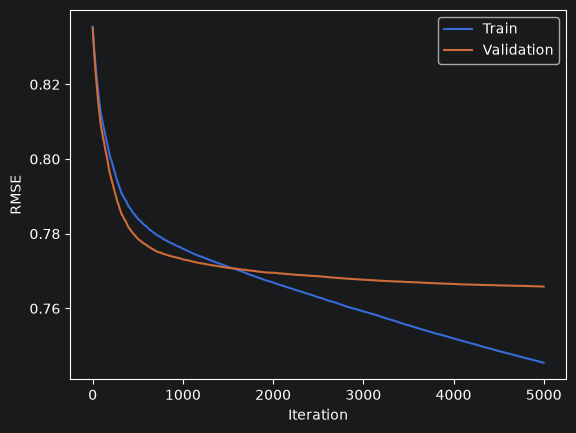

In [15]:
evals_result = cat_reg.get_evals_result()

print(evals_result.keys())

# evals_result['learn']['RMSE']: 학습 데이터 RMSE 변화.
# evals_result['validation']['RMSE']: 평가 데이터 RMSE 변화.
plt.plot(evals_result['learn']['RMSE'], label='Train')
plt.plot(evals_result['validation']['RMSE'], label='Validation')
plt.ylabel('RMSE')
plt.xlabel('Iteration')
plt.legend()
plt.show()


# Train과 Test 간의 오차는 있지만 감소하는 추세
# == 모델이 학습을 할수록 예측 성능이 좋아지고 있다.

## 15. Feature 중요도 확인

Feature 중요도는 모델이 예측할 때 어떤 입력 변수를 많이 활용했는지 보여준다.

추천 시스템에서는 “왜 이 항목이 추천되었는가?”를 설명해야 하는 경우가 많다.  
예를 들어 방문지 이름, 이동수단, 여행 스타일 중 어떤 정보가 만족도 예측에 많이 쓰였는지 확인하면 모델의 판단 근거를 조금 더 설명할 수 있다.

CatBoost 같은 트리 기반 모델에서 중요도는 보통 분기와 손실 감소에 얼마나 기여했는지 기준으로 계산된다.  
중요도가 높다고 해서 반드시 만족도의 원인이라는 뜻은 아니며, 모델이 예측에 자주 참고한 변수로 해석하는 것이 안전하다.


In [17]:
feat_importances_df = pd.DataFrame({
    'column' : X_train.columns,
    'importance' : cat_reg.feature_importances_
})

feat_importances_df = feat_importances_df.sort_values('importance', ascending=False)
display(feat_importances_df)

,column,importance
12,VISIT_AREA_NM,11.995952
9,TRAVEL_STYL_8,10.953335
6,TRAVEL_STYL_5,9.069122
5,TRAVEL_STYL_4,8.750092
7,TRAVEL_STYL_6,8.512182
1,AGE_GRP,7.982201
10,TRAVEL_MOTIVE_1,7.962153
8,TRAVEL_STYL_7,7.619823
2,TRAVEL_STYL_1,7.600401
3,TRAVEL_STYL_2,7.560392


## 16. 예측과 점수 확인

회귀 기반 추천에서는 모델이 예측한 숫자 점수가 추천 정렬의 기준이 된다.  
따라서 추천 함수를 만들기 전에, 이 예측 점수가 어느 정도 믿을 만한지 먼저 확인해야 한다.

여기서 예측 점수는 확률이 아니다.  
`DGSTFN` 만족도 점수를 예측한 값이므로 “이 후보 방문지에 대해 모델이 예상한 만족도”로 해석한다.

- MAE: 평균적으로 몇 점 정도 틀리는지 직관적으로 볼 수 있음.
- RMSE: 큰 오차를 더 강하게 반영함.
- R2: 모델이 target 변화를 얼마나 설명하는지 확인함.

추천에서는 단일 샘플 하나를 맞혔는지보다, 여러 후보의 예측 점수를 비교했을 때 의미 있는 순서가 만들어지는지가 중요하다.


In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# sklearn.metrics를 이용해서 수치를 확인하려면 y와 y_pred가 필요하다
y_test_pred = cat_reg.predict(X_test) # 예측

mae = mean_absolute_error(y_test, y_test_pred)
rmse =root_mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)


print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

# 평가 데이터와 실제 만족도를 비교
sample_X = X_test.iloc[[0]] # Test 입력값 중 0번 행만 가져오기
sample_y = y_test.iloc[[0]] # Test 정답값 중 0번 행만 가져오기
sample_pred =cat_reg.predict(sample_X)[0] # 예측값

display(sample_X)
print("실제 만족도: ", sample_y)
print("예측 만족도", sample_pred)


# 실제 만족도와 예측 만족도 MAE 오차 범위가 유사하게 형성되면
# 모델 학습은 잘 된것으로 생각할 수 있음.
# 다만, 학습이 잘 되었다고 해서 모델의 성능이 좋다고는 판단하기 어렵다.
# -> 전체 평가 지표를 확인해볼 필요가 있음.

MAE: 0.5711
RMSE: 0.7658
R2: 0.1594


,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM
28442,남,60,1,1,5,3,1,5,1,6,2,1,로얄엠포리움호텔,자가용


실제 만족도:  28442    3.0
Name: DGSTFN, dtype: float64
예측 만족도 3.573454268841124


### 추천 함수

추천 함수는 “후보 장소를 하나씩 바꿔 넣어 예측 만족도를 계산하고, 점수가 높은 장소를 정렬하는 함수”이다.

처리 흐름은 다음과 같다.

1. 사용자 조건은 고정한다.
2. 후보 방문지만 하나씩 바꾼다.
3. 각 후보 방문지에 대한 예상 만족도를 예측한다.
4. 예측 만족도가 높은 순서로 정렬해 상위 N개를 추천한다.

이 과정에서 모델은 매번 “사용자 조건 + 후보 방문지” 조합에 대해 만족도 점수를 예측한다.  
즉, 추천 함수는 모델의 `predict()` 결과를 여러 번 모아서 순위를 만드는 역할을 한다.


## 17. 추천 후보가 될 전체 방문지 목록 확인

In [34]:
visit_areas = travel_df['VISIT_AREA_NM'].unique()
print(visit_areas)

# 학습된 모델에 사용자 조건을 고정한 뒤
# 방문자 목록을 하나씩 바꿔넣으면서 만족도를 예측

<ArrowStringArray>
[        '미스틱3도',       '에스제이렌트카',          '법환식당',        '에코랜드호텔',
     '윤스타피자앤파스타',      '서정리역 1호선',          '동문식당',          '해녀식당',
         '알맞은시간',          '애월온기',
 ...
        '제주초계한우',        '숲속의컨벤션',  '제주신화월드 S BAR',         '월미전망대',
         '네이처파크',           '고옥정',  '네스트호텔 쿤스트라운지',        '제이스바버샵',
 '블라제리조트 전기차충전소',           '미미슈']
Length: 10711, dtype: str


## 18. 추천 함수에 넣을 사용자 입력값 구조 확인

In [35]:
print(X_test.iloc[0].values)

# 장소가 입력 데이터의 12번째 컬럼임을 확인
# [중요] 입력 데이터의 순서는 학습 데이터와 동일해야한다!!

['남' np.int64(60) np.int64(1) np.int64(1) np.int64(5) np.int64(3)
 np.int64(1) np.int64(5) np.int64(1) np.int64(6) np.int64(2) np.int64(1)
 '로얄엠포리움호텔' '자가용']


## 19. 예측 점수 기반 추천 결과 생성

이제 학습된 CatBoost 모델을 추천 함수 안에서 사용한다.

중요한 해석 포인트는 다음이다.

- `user_input`: 한 명의 사용자 조건과 후보 방문지 자리를 담은 입력값임.
- `candidate_input[-2]`: 방문지 이름이 들어가는 위치임.
- `dgstfn_pred`: 모델이 예측한 예상 만족도 점수임.
- 추천 결과는 `dgstfn_pred`가 높은 순서로 정렬됨.

따라서 최종 표의 첫 번째 행은 “현재 사용자 조건에서 모델이 가장 높은 만족도를 예상한 방문지”로 해석한다.


In [38]:
# 장소 추천 함수
# 사용자 입력을 전달 받아 모델에 cat_boost 모델을 이용해
# 장소별 만족도 예측
# 결과로 보여줄 장소의 수(추천 수)는 topn
def recommend_visit_area(user_input, topn=10):
    #만족도 예측 결과를 저장할 list
    dgstfn_results = []

    #방문지 목록의 모든 방문지와 user_input을 이용해서 만족도 예측
    for area in visit_areas :
        #원본 유지를 위해 user input 복사
        candidate_input = user_input.copy()

        #사용자 입력(14컬럼) 값 중 장소 컬럼(뒤에서 두번쨰 ) 값을
        #area로 치환
        candidate_input[-2] = area

        #CatBoost 모델은 학습/예측 시 값이 DataFrame(2차원) 형태
        candidate_df = pd.DataFrame(
            [candidate_input],
            columns=cat_columns        )
        # 현재 area에 대한 만족도 예측
        dgstfn = cat_reg.predict(candidate_df)[0]
        dgstfn_results.append(dgstfn)
    result_df = pd.DataFrame({
        'visit_area_nm' : visit_areas,
        'dgstfn_pred' : dgstfn_results,
    })

    # 추천을 위해 만족도 내림차순으로 정렬
    result_df = result_df.sort_values('dgstfn_pred', ascending=False)

    return result_df.head(topn) # topn만큼의 행반환

In [39]:
# 예시 사용자 입력
# 장소를 나타내는 'XXXXXXXXXXX' 값이 계속 바뀌면서 장소별 만족도를 예측
user_input = ['남', 60,    1, 1, 5, 3, 1, 5, 1, 6,     2, 1, 'XXXXXXXXXX', '자가용']

recommend_visit_area(user_input)

,visit_area_nm,dgstfn_pred
1017,어영공원,4.222414
1807,그랜드조선제주 아리아,4.218763
53,울산공항,4.211271
406,숙성도 노형점,4.210220
257,함덕해수욕장,4.201435
614,사려니숲길,4.201385
3540,세화갈비,4.201151
146,숙성도 함덕점,4.184161
272,아침미소목장,4.184032
676,파라다이스시티,4.183861


## 20. 여러 사용자 조건으로 예측해보기

하나의 사용자 입력만 확인하면 추천 함수가 실제로 사용자 조건에 따라 달라지는지 보기 어렵다.

이번 셀에서는 평가 데이터에서 사용자 조건 몇 개를 가져와, 여러 후보 방문지에 대한 예상 만족도를 비교한다.  
이렇게 보면 “사용자 조건이 달라지면 같은 방문지라도 예측 만족도가 달라질 수 있다”는 점을 확인할 수 있다.

주의할 점은 이번 셀이 **전체 방문지 중 최종 추천을 다시 구하는 셀은 아니라는 것**이다.  
아래 코드에서는 `value_counts().head(5)`로 데이터에 자주 등장한 방문지 5개만 골라 비교한다.

따라서 이 셀의 결과는 다음처럼 해석한다.

```text
전체 방문지 중 추천 결과가 아니라,
선택한 후보 5개 안에서 사용자별 예상 만족도를 비교한 결과이다.
```

확인할 내용은 다음이다.

- 행: 서로 다른 사용자 조건
- 열: 비교 대상으로 선택한 후보 방문지 5개
- 값: CatBoost 모델이 예측한 예상 만족도 점수

점수가 높은 후보일수록 현재 사용자 조건에서 우선 추천될 가능성이 높다.  
다만 후보를 5개로 제한했기 때문에, 이 표에 없는 다른 방문지가 실제 전체 추천에서는 더 높은 점수를 받을 수도 있다.


In [44]:
# 입력된 사용자가 전달 받은 장소 중 만족도가 높은 순서로 반환
def recommend_visit_area_input_areas(user_input, visit_areas):

    dgstfn_results = []

    for area in visit_areas:
        candidate_input = user_input.copy()
        candidate_input[-2] = area

        candidate_df = pd.DataFrame(
            [candidate_input],
            columns=cat_columns
        )

        dgstfn = cat_reg.predict(candidate_df)[0]
        dgstfn_results.append(dgstfn)

    results_df = pd.DataFrame({
        'visit_area': visit_areas,
        'dgstfn_pred': dgstfn_results
    })

    result_df \
        = results_df.sort_values('dgstfn_pred', ascending=False)

    return result_df

In [52]:
# 사용자 생플
sample_users_df = X_test.head(3)

# 장소 지정
# display(pd.DataFrame(visit_areas).head(30))
sample_visit_areas = ['해녀식당', '아일랜드 리솜', '정방폭포', '뽀로로앤타요테마파크제주', '섭지코지']

recommend_results = []

for user_idx, user_info in sample_users_df.iterrows():
    # print(user_idx)
    # print(user_info)

    # 시리즈 -> 리스트로 변환
    user_input = user_info.values.tolist()

    # 함수 호출
    result_df = recommend_visit_area_input_areas(
        user_input,
        sample_visit_areas
    )
    # 사용자 구분을 위해서 user_idx 추가
    result_df['user_idx'] = user_idx

    recommend_results.append(result_df)

# list[DataFrame] -> DataFrame으로 합침
recommend_result_df = pd.concat(recommend_results, ignore_index=True)

recommend_result_df = recommend_result_df[['user_idx', 'visit_area', 'dgstfn_pred']]
display(recommend_result_df)

,user_idx,visit_area,dgstfn_pred
0,28442,섭지코지,4.047955
1,28442,정방폭포,4.015448
2,28442,아일랜드 리솜,3.993497
3,28442,뽀로로앤타요테마파크제주,3.870362
4,28442,해녀식당,3.863058
5,22538,정방폭포,4.341083
6,22538,아일랜드 리솜,4.339874
7,22538,섭지코지,4.329375
8,22538,해녀식당,4.314249
9,22538,뽀로로앤타요테마파크제주,4.309153


In [ ]:
# t